# CSE754 - PHASE 3: Real Data Integration (LIVECell)

*   List item
*   List item



**Author:** Sadia Ruhama — MSc Proposal (CSE 754)

Phases 1-3 ran entirely on synthetic data. This notebook closes that gap by
building a **real single-cell image dataset** from the
[LIVECell dataset](https://sartorius-research.github.io/LIVECell/)
(Edlund et al., *Nature Methods* 2021) — one of the three datasets named
in the proposal (Slide 31) — and writing it into the exact
`cse754/data/{train,val,test}/<class_name>/*.png` `ImageFolder` layout
that Phase 2/3's `build_real_datasets()` already expects. **No pipeline
code changes are needed** — after this notebook finishes, you set
`cfg.USE_SYNTHETIC_DATA = False` (plus `num_classes` / `rare_class_idx`,
printed at the end of this notebook) in Phase 2 or Phase 3 and rerun them
unchanged.

**What LIVECell actually is, and the one honest caveat up front:**
LIVECell contains ~1.6M annotated cells across **8 real cell lines**
(A172, BT474, BV2, Huh7, MCF7, SHSY5Y, SkBr3, SKOV3), imaged by
phase-contrast microscopy, with instance-segmentation-quality bounding
boxes for every cell. The 8 cell lines are **not naturally rare** relative
to each other — LIVECell was collected to be roughly balanced across
types. To actually exercise the rare-class / annotation-bottleneck
scenario the proposal targets, this notebook **deliberately subsamples
one real cell line down to a small fraction in the training pool only**
(mirroring Phase 2's `rare_fraction`), while keeping validation/test sets
balanced so evaluation is meaningful. That's a real, defensible way to
study few-shot rare-category learning on real microscopy images — but be
upfront in the write-up that the imbalance is constructed, not a natural
property of these particular cell lines.

**License note:** LIVECell is released under CC BY-NC-SA 4.0
(non-commercial). Fine for coursework; flag it if this ever becomes a
publication.

**Compute/storage note:** LIVECell's images require ~1.3 GB unzipped
(small compared to JUMP Cell Painting, which is multiple terabytes and
not practical to pull into a Colab session). Only the small single-cell
PNG crops this notebook produces are written to Drive; the raw LIVECell
download stays on the ephemeral Colab disk and can be deleted after.

## 1. Setup — installs and Google Drive

In [ ]:
!pip install -q -U pycocotools pillow requests tqdm

import os
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/cse754'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')          # ImageFolder target (matches Phase 2/3)
OUT_DIR = os.path.join(PROJECT_ROOT, 'outputs')
PHASE4_DIR = os.path.join(OUT_DIR, 'phase4')

# Raw LIVECell download stays on local Colab disk, not Drive -- it's
# intermediate data, not a deliverable, and Drive I/O for ~1.3GB of TIFFs
# would be far slower than local disk.
RAW_DIR = '/content/livecell_raw'
IMAGES_DIR = os.path.join(RAW_DIR, 'images')
ANN_DIR = os.path.join(RAW_DIR, 'annotations')

for d in [PROJECT_ROOT, DATA_DIR, OUT_DIR, PHASE4_DIR, RAW_DIR, IMAGES_DIR, ANN_DIR]:
    os.makedirs(d, exist_ok=True)

print('Drive project root:', PROJECT_ROOT)
print('Local raw-data dir :', RAW_DIR)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 5.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
Mounted at /content/drive
Drive project root: /content/drive/MyDrive/cse754
Local raw-data dir : /content/livecell_raw


## 2. Config

In [ ]:
from dataclasses import dataclass, field
from typing import Tuple

@dataclass
class LiveCellConfig:
    # ---- Download sources (verified working URLs as of this writing) ----
    images_zip_url: str = ('http://livecell-dataset.s3.eu-central-1.amazonaws.com/'
                            'LIVECell_dataset_2021/images.zip')
    ann_urls: dict = field(default_factory=lambda: {
        'train': 'http://livecell-dataset.s3.eu-central-1.amazonaws.com/LIVECell_dataset_2021/annotations/LIVECell/livecell_coco_train.json',
        'val':   'http://livecell-dataset.s3.eu-central-1.amazonaws.com/LIVECell_dataset_2021/annotations/LIVECell/livecell_coco_val.json',
        'test':  'http://livecell-dataset.s3.eu-central-1.amazonaws.com/LIVECell_dataset_2021/annotations/LIVECell/livecell_coco_test.json',
    })

    cell_types: Tuple[str, ...] = ('A172', 'BT474', 'BV2', 'Huh7', 'MCF7', 'SHSY5Y', 'SkBr3', 'SKOV3')

    # ---- Crop extraction ----
    crop_size: int = 224          # output PNG size (square, matches cfg.image_size in Phase 2/3)
    bbox_padding_frac: float = 0.25   # extra context around each cell's bounding box

    # ---- How many crops to build per split/class (bounds runtime + Drive usage) ----
    # Common (non-rare) classes:
    train_crops_per_common_class: int = 400
    val_crops_per_class: int = 80
    test_crops_per_class: int = 100

    # Rare class: constructed imbalance, applied to the TRAIN split only.
    rare_cell_type: str = 'BV2'          # smallest, most morphologically distinct -> good "rare" pick
    train_crops_for_rare_class: int = 15  # ~3-4% of the common-class budget, matching Phase 2's rare_fraction

    max_images_scanned_per_class: int = 60   # how many source LIVECell images to pull crops from per class
    max_crops_per_source_image: int = 25     # cap crops taken from any single source image (avoid over-correlated crops)

    seed: int = 42


lc_cfg = LiveCellConfig()
print(lc_cfg)

LiveCellConfig(images_zip_url='http://livecell-dataset.s3.eu-central-1.amazonaws.com/LIVECell_dataset_2021/images.zip', ann_urls={'train': 'http://livecell-dataset.s3.eu-central-1.amazonaws.com/LIVECell_dataset_2021/annotations/LIVECell/livecell_coco_train.json', 'val': 'http://livecell-dataset.s3.eu-central-1.amazonaws.com/LIVECell_dataset_2021/annotations/LIVECell/livecell_coco_val.json', 'test': 'http://livecell-dataset.s3.eu-central-1.amazonaws.com/LIVECell_dataset_2021/annotations/LIVECell/livecell_coco_test.json'}, cell_types=('A172', 'BT474', 'BV2', 'Huh7', 'MCF7', 'SHSY5Y', 'SkBr3', 'SKOV3'), crop_size=224, bbox_padding_frac=0.25, train_crops_per_common_class=400, val_crops_per_class=80, test_crops_per_class=100, rare_cell_type='BV2', train_crops_for_rare_class=15, max_images_scanned_per_class=60, max_crops_per_source_image=25, seed=42)


## 3. Download annotations (small JSON files) and images.zip (~1.3GB unzipped)

In [ ]:
import requests
from tqdm import tqdm
import zipfile

def download_file(url: str, dest_path: str, chunk_size: int = 1 << 20):
    if os.path.exists(dest_path) and os.path.getsize(dest_path) > 0:
        print(f'  already downloaded: {dest_path}')
        return
    resp = requests.get(url, stream=True, timeout=60)
    resp.raise_for_status()
    total = int(resp.headers.get('content-length', 0))
    with open(dest_path, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True, desc=os.path.basename(dest_path)) as pbar:
        for chunk in resp.iter_content(chunk_size=chunk_size):
            if chunk:
                f.write(chunk)
                pbar.update(len(chunk))

print('Downloading annotation JSONs...')
ann_paths = {}
for split, url in lc_cfg.ann_urls.items():
    dest = os.path.join(ANN_DIR, f'livecell_coco_{split}.json')
    download_file(url, dest)
    ann_paths[split] = dest

print('Downloading images.zip (this is the big one, ~1.3GB unzipped)...')
zip_path = os.path.join(RAW_DIR, 'images.zip')
download_file(lc_cfg.images_zip_url, zip_path)

if not os.path.exists(os.path.join(IMAGES_DIR, 'livecell_train_val_images')):
    print('Unzipping images.zip...')
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(RAW_DIR)
    print('Done. Contents of', RAW_DIR, ':', os.listdir(RAW_DIR))
else:
    print('Already unzipped.')

livecell_coco_train.json: 100%|██████████| 551M/551M [00:19<00:00, 27.9MB/s]
livecell_coco_val.json: 100%|██████████| 97.3M/97.3M [00:04<00:00, 24.0MB/s]
livecell_coco_test.json: 100%|██████████| 261M/261M [00:10<00:00, 25.3MB/s]


images.zip: 100%|██████████| 1.24G/1.24G [00:37<00:00, 33.1MB/s]


Unzipping images.zip...
Done. Contents of /content/livecell_raw : ['annotations', 'images', 'images.zip']


## 4. Load COCO annotations and index images by (split, cell type)

LIVECell's COCO files use a single `cell` category for every instance —
the *cell type* (our class label) comes from parsing the filename prefix
(e.g. `A172_Phase_...tif` -> `A172`), not from `category_id`.

In [ ]:
from pycocotools.coco import COCO

def cell_type_from_filename(file_name: str) -> str:
    # e.g. 'A172_Phase_C7_1_02d16h00m_2.tif' -> 'A172'
    return file_name.split('_Phase_')[0]

cocos = {split: COCO(path) for split, path in ann_paths.items()}

# LIVECell physically stores train+val images together, test images separately.
IMAGE_SUBDIR = {
    'train': 'livecell_train_val_images',
    'val': 'livecell_train_val_images',
    'test': 'livecell_test_images',
}

# NOTE: LIVECell's own README diagram implies a per-cell-type subfolder
# under each split (e.g. livecell_train_val_images/A172/...), but in
# practice the extracted .tif files sit FLAT inside
# livecell_train_val_images/ and livecell_test_images/ -- the README's tree
# is describing the filename convention, not real subdirectories (confirmed
# against a user report on the LIVECell GitHub issue tracker). Rather than
# hardcode either layout and risk silently resolving to nonexistent paths
# again, we build an index of every .tif actually on disk and look files up
# by filename -- this works regardless of which layout is really there.
print('Indexing extracted image files (building filename -> path map)...')
FILENAME_INDEX = {}
for root, _, files in os.walk(IMAGES_DIR):
    for fn in files:
        if fn.lower().endswith('.tif'):
            FILENAME_INDEX[fn] = os.path.join(root, fn)
print(f'Indexed {len(FILENAME_INDEX):,} .tif files under {IMAGES_DIR}')
if len(FILENAME_INDEX) == 0:
    print('  [WARN] No .tif files found at all -- check that images.zip actually '
          'unzipped correctly (see Section 3 output above) before continuing.')

def resolve_image_path(split: str, file_name: str):
    '''Returns a real path if the file is on disk, else None. Ignores `split`
    for lookup purposes since the index is built once over the whole
    IMAGES_DIR -- kept as a parameter for a clear call-site and in case a
    filename collides across splits in some future re-run.'''
    return FILENAME_INDEX.get(file_name)

# Sanity check: confirm a few images per split actually resolve now.
for split, coco in cocos.items():
    img_ids = coco.getImgIds()
    sample_id = img_ids[0]
    sample_name = coco.loadImgs(sample_id)[0]['file_name']
    sample_path = resolve_image_path(split, sample_name)
    print(f'{split:6s}: {len(img_ids):6d} images total | example filename -> {sample_name} '
          f'| resolved -> {sample_path}')

loading annotations into memory...
Done (t=20.99s)
creating index...
index created!
loading annotations into memory...
Done (t=2.41s)
creating index...
index created!
loading annotations into memory...
Done (t=8.69s)
creating index...
index created!
Indexing extracted image files (building filename -> path map)...
Indexed 5,239 .tif files under /content/livecell_raw/images
train :   3253 images total | example filename -> BT474_Phase_A3_2_00d04h00m_3.tif | resolved -> /content/livecell_raw/images/livecell_train_val_images/BT474_Phase_A3_2_00d04h00m_3.tif
val   :    570 images total | example filename -> BT474_Phase_B3_1_00d12h00m_1.tif | resolved -> /content/livecell_raw/images/livecell_train_val_images/BT474_Phase_B3_1_00d12h00m_1.tif
test  :   1564 images total | example filename -> BT474_Phase_D3_1_04d04h00m_3.tif | resolved -> /content/livecell_raw/images/livecell_test_images/BT474_Phase_D3_1_04d04h00m_3.tif


## 5. Group images by cell type per split

In [ ]:
import numpy as np
from collections import defaultdict

def images_by_cell_type(coco, split):
    grouped = defaultdict(list)
    for img_id in coco.getImgIds():
        info = coco.loadImgs(img_id)[0]
        ctype = cell_type_from_filename(info['file_name'])
        grouped[ctype].append(img_id)
    return grouped

grouped_by_split = {split: images_by_cell_type(coco, split) for split, coco in cocos.items()}

for split, grouped in grouped_by_split.items():
    counts = {k: len(v) for k, v in grouped.items()}
    print(f'{split}: images per cell type -> {counts}')

train: images per cell type -> {'BT474': 429, 'A172': 388, 'MCF7': 469, 'BV2': 386, 'Huh7': 390, 'SkBr3': 449, 'SKOV3': 293, 'SHSY5Y': 449}
val: images per cell type -> {'BT474': 75, 'A172': 68, 'MCF7': 82, 'BV2': 70, 'Huh7': 66, 'SkBr3': 79, 'SKOV3': 51, 'SHSY5Y': 79}
test: images per cell type -> {'BT474': 168, 'A172': 152, 'MCF7': 184, 'Huh7': 216, 'BV2': 152, 'SkBr3': 176, 'SKOV3': 340, 'SHSY5Y': 176}


## 6. Crop single cells from bounding boxes and save as PNGs

Uses LIVECell's ground-truth instance annotations directly in place of the
proposal's SAM2 preprocessing step (Slide 28) -- real annotated boundaries
are already available for this dataset, so an automatic segmenter isn't
needed here.

In [ ]:
from PIL import Image

rng = np.random.RandomState(lc_cfg.seed)


def load_gray_as_rgb(path: str) -> Image.Image:
    img = Image.open(path)
    if img.mode != 'RGB':
        img = img.convert('L').convert('RGB')
    return img


def crop_one_cell(pil_img: Image.Image, bbox, cfg: LiveCellConfig) -> Image.Image:
    x, y, w, h = bbox
    pad_x, pad_y = w * cfg.bbox_padding_frac, h * cfg.bbox_padding_frac
    left = max(0, int(x - pad_x))
    top = max(0, int(y - pad_y))
    right = min(pil_img.width, int(x + w + pad_x))
    bottom = min(pil_img.height, int(y + h + pad_y))
    if right <= left or bottom <= top:
        return None
    crop = pil_img.crop((left, top, right, bottom))
    # pad to square before resizing so cell shape/aspect ratio isn't distorted
    side = max(crop.width, crop.height)
    square = Image.new('RGB', (side, side), (0, 0, 0))
    square.paste(crop, ((side - crop.width) // 2, (side - crop.height) // 2))
    return square.resize((cfg.crop_size, cfg.crop_size), Image.BILINEAR)


def build_crops_for_split(split: str, coco: 'COCO', grouped, cfg: LiveCellConfig, out_root: str):
    class_counts = {}
    for cell_type in cfg.cell_types:
        img_ids = grouped.get(cell_type, [])
        if not img_ids:
            print(f'  [WARN] no images found for {cell_type} in {split} split -- skipping')
            class_counts[cell_type] = 0
            continue

        if cell_type == cfg.rare_cell_type and split == 'train':
            target_crops = cfg.train_crops_for_rare_class
        elif split == 'train':
            target_crops = cfg.train_crops_per_common_class
        elif split == 'val':
            target_crops = cfg.val_crops_per_class
        else:
            target_crops = cfg.test_crops_per_class

        out_dir = os.path.join(out_root, split, cell_type)
        os.makedirs(out_dir, exist_ok=True)

        shuffled_ids = list(img_ids)
        rng.shuffle(shuffled_ids)
        shuffled_ids = shuffled_ids[:cfg.max_images_scanned_per_class]

        saved = 0
        not_found = 0
        for img_id in shuffled_ids:
            if saved >= target_crops:
                break
            info = coco.loadImgs(img_id)[0]
            img_path = resolve_image_path(split, info['file_name'])
            if not img_path or not os.path.exists(img_path):
                not_found += 1
                continue
            pil_img = load_gray_as_rgb(img_path)

            ann_ids = coco.getAnnIds(imgIds=img_id)
            anns = coco.loadAnns(ann_ids)
            rng.shuffle(anns)

            n_from_this_image = 0
            for ann in anns:
                if saved >= target_crops or n_from_this_image >= cfg.max_crops_per_source_image:
                    break
                crop = crop_one_cell(pil_img, ann['bbox'], cfg)
                if crop is None:
                    continue
                out_path = os.path.join(out_dir, f'{cell_type}_{split}_{saved:05d}.png')
                crop.save(out_path)
                saved += 1
                n_from_this_image += 1

        class_counts[cell_type] = saved
        note = f' | {not_found} source images not found on disk' if not_found else ''
        print(f'  [{split}] {cell_type:8s}: saved {saved:4d} crops '
              f'(target {target_crops}, from {len(shuffled_ids)} source images){note}')
    return class_counts


all_class_counts = {}
for split, coco in cocos.items():
    print(f'--- Building crops for split: {split} ---')
    all_class_counts[split] = build_crops_for_split(
        split, coco, grouped_by_split[split], lc_cfg, DATA_DIR)

--- Building crops for split: train ---
  [train] A172    : saved  400 crops (target 400, from 60 source images)
  [train] BT474   : saved  400 crops (target 400, from 60 source images)
  [train] BV2     : saved   15 crops (target 15, from 60 source images)
  [train] Huh7    : saved  400 crops (target 400, from 60 source images)
  [train] MCF7    : saved  400 crops (target 400, from 60 source images)
  [train] SHSY5Y  : saved  400 crops (target 400, from 60 source images)
  [train] SkBr3   : saved  400 crops (target 400, from 60 source images)
  [train] SKOV3   : saved  400 crops (target 400, from 60 source images)
--- Building crops for split: val ---
  [val] A172    : saved   80 crops (target 80, from 60 source images)
  [val] BT474   : saved   80 crops (target 80, from 60 source images)
  [val] BV2     : saved   80 crops (target 80, from 60 source images)
  [val] Huh7    : saved   80 crops (target 80, from 60 source images)
  [val] MCF7    : saved   80 crops (target 80, from 60 sour

## 7. Verify the resulting `ImageFolder` layout and report the class index
  mapping Phase 2/3's `Config` needs

`torchvision.datasets.ImageFolder` assigns class indices by **sorted**
folder name, so we derive the mapping directly from what's on disk rather
than assuming an order.

In [ ]:
train_classes_on_disk = sorted(os.listdir(os.path.join(DATA_DIR, 'train')))
class_to_idx = {c: i for i, c in enumerate(train_classes_on_disk)}
rare_class_idx = class_to_idx[lc_cfg.rare_cell_type]

print('Class -> index mapping (this is what ImageFolder will use):')
for c, i in class_to_idx.items():
    print(f'  {i}: {c}')
print()
print(f'>>> In Phase 2/3 Config, set: <<<')
print(f'    USE_SYNTHETIC_DATA = False')
print(f'    num_classes        = {len(class_to_idx)}')
print(f'    rare_class_idx     = {rare_class_idx}   # ({lc_cfg.rare_cell_type})')

final_counts = {
    'class_to_idx': class_to_idx,
    'rare_class_idx': rare_class_idx,
    'rare_cell_type': lc_cfg.rare_cell_type,
    'counts_by_split': all_class_counts,
}
with open(os.path.join(PHASE4_DIR, 'livecell_dataset_summary.json'), 'w') as f:
    import json
    json.dump(final_counts, f, indent=2)
print('\nSaved dataset summary to', os.path.join(PHASE4_DIR, 'livecell_dataset_summary.json'))

Class -> index mapping (this is what ImageFolder will use):
  0: A172
  1: BT474
  2: BV2
  3: Huh7
  4: MCF7
  5: SHSY5Y
  6: SKOV3
  7: SkBr3

>>> In Phase 2/3 Config, set: <<<
    USE_SYNTHETIC_DATA = False
    num_classes        = 8
    rare_class_idx     = 2   # (BV2)

Saved dataset summary to /content/drive/MyDrive/cse754/outputs/phase4/livecell_dataset_summary.json


## 8. Sanity-check: view a few crops per split

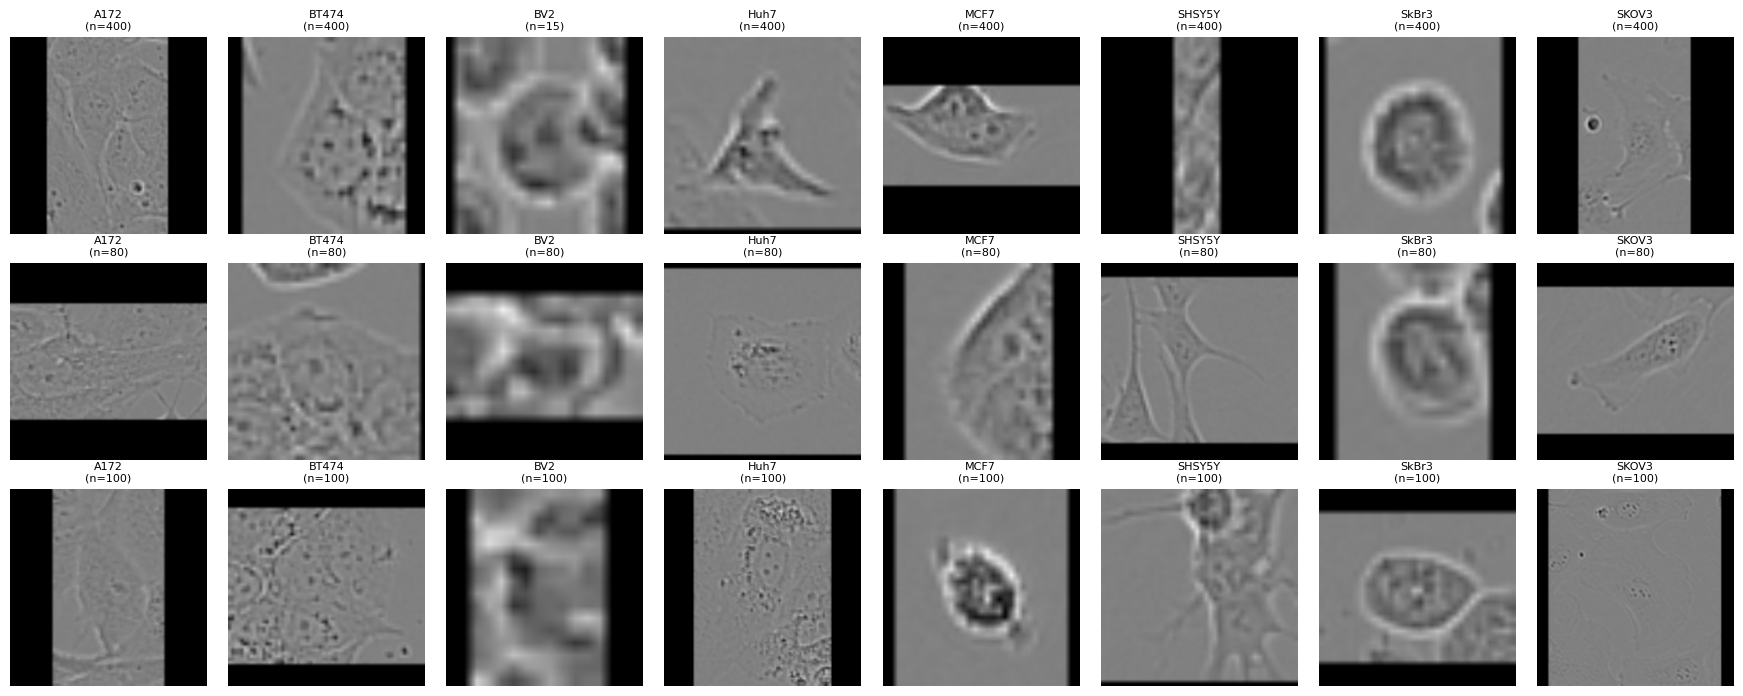

Saved sample grid to /content/drive/MyDrive/cse754/outputs/phase4/livecell_crop_samples.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, len(lc_cfg.cell_types), figsize=(2.2 * len(lc_cfg.cell_types), 7))
for row, split in enumerate(['train', 'val', 'test']):
    for col, cell_type in enumerate(lc_cfg.cell_types):
        class_dir = os.path.join(DATA_DIR, split, cell_type)
        files = os.listdir(class_dir) if os.path.isdir(class_dir) else []
        ax = axes[row, col]
        if files:
            img = Image.open(os.path.join(class_dir, files[0]))
            ax.imshow(img)
        ax.set_title(f'{cell_type}\n(n={len(files)})', fontsize=8)
        ax.axis('off')
    axes[row, 0].set_ylabel(split, fontsize=10)
plt.tight_layout()
plot_path = os.path.join(PHASE4_DIR, 'livecell_crop_samples.png')
plt.savefig(plot_path, dpi=130)
plt.show()
print('Saved sample grid to', plot_path)

## 9. (Optional) Free up local disk

The Drive copy (`cse754/data/...`) is what Phase 2/3 will read from -- the
raw LIVECell download on local disk is no longer needed once the crops
above look right.

In [ ]:
CLEANUP_RAW_DOWNLOAD = False  # flip to True once you've checked Section 8's sample grid

if CLEANUP_RAW_DOWNLOAD:
    import shutil
    shutil.rmtree(RAW_DIR, ignore_errors=True)
    print('Removed', RAW_DIR)
else:
    print('Leaving raw download in place at', RAW_DIR, '(safe to delete manually later).')

Leaving raw download in place at /content/livecell_raw (safe to delete manually later).


## Notes / next steps

- **Run Phase 2 or Phase 3 next, unchanged**, except in `Config`:
  `USE_SYNTHETIC_DATA = False`, `num_classes` and `rare_class_idx` set to
  the values printed in Section 7. `build_real_datasets()` already reads
  exactly this `cse754/data/{train,val,test}/<class>/*.png` layout, so
  nothing else in the training/AL/ablation code needs to change.
- **If class counts in Section 7/8 look thin** (e.g. a cell type had fewer
  source images than `max_images_scanned_per_class` could sample from),
  raise `max_images_scanned_per_class` and/or `max_crops_per_source_image`
  and rerun Section 6 -- it skips files already on disk, so it's cheap to
  top up.
- **Cross-platform splits (proposal Slide 31)**: LIVECell's `train`/`val`
  images all come from the *same* Incucyte imaging system as `test`, just
  different wells/timepoints -- so this split is a same-platform
  generalization test, not the cross-*platform* (different microscope/lab)
  test the proposal describes. Genuine cross-platform evaluation would
  need a second dataset (e.g. a JUMP Cell Painting subset) held out
  entirely as a second test set -- worth flagging as a limitation, or as
  the next real step if time allows.
- **Rarity is constructed, not natural** (see the note at the top) --
  state this plainly in the write-up so the rare-class results are read
  correctly: this tests the *method's* ability to learn from few labels of
  a real, morphologically real cell type, not a claim that BV2 cells are
  naturally rare in practice.